In [1]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
print(pd.unique(fish['Species']))

fish_input=fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_input.head()

fish_target=fish['Species']

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [3]:
from sklearn.model_selection import train_test_split

train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target,random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()

ss.fit(train_input)

train_scaled=ss.transform(train_input)

test_scaled=ss.transform(test_input)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [7]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [8]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [9]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [10]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [11]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [12]:
print(lr.classes_)

['Bream' 'Smelt']


In [13]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [14]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [15]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [16]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [17]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [18]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [21]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [22]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [23]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [24]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

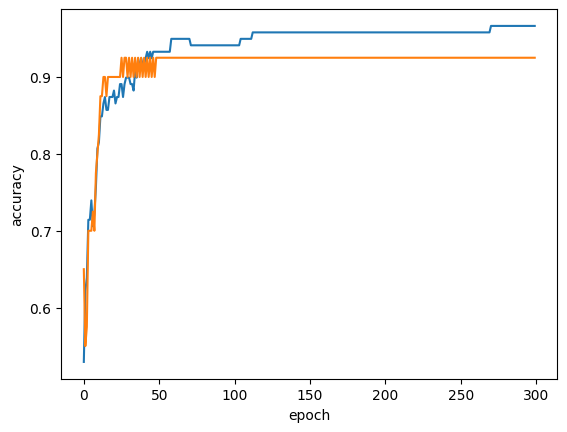

In [25]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [26]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [27]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [28]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [29]:
from sklearn.model_selection import train_test_split

train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()

ss.fit(train_input)

train_scaled=ss.transform(train_input)

test_scaled=ss.transform(test_input)

In [31]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

LogisticRegression(C=20, max_iter=1000)

In [32]:
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

In [33]:
test_data_scaled = ss.transform(test_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
predictions = lr.predict(test_data_scaled)
print(predictions)

['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']


In [35]:
proba = lr.predict_proba(test_data_scaled)
print(f"클래스(물고기 종류) 순서: {lr.classes_}\n")
print(np.round(proba, decimals=3))

클래스(물고기 종류) 순서: ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']

[[0.451 0.049 0.008 0.006 0.384 0.    0.102]
 [0.    0.002 0.048 0.    0.009 0.941 0.   ]
 [0.    0.    0.287 0.713 0.    0.    0.   ]
 [0.    0.013 0.512 0.001 0.461 0.002 0.011]
 [0.368 0.094 0.    0.    0.009 0.    0.528]]


In [36]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [37]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [38]:
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [39]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [40]:
sc_10 = SGDClassifier(loss='hinge', max_iter=10, random_state=42)
sc_10.fit(train_scaled, train_target)
score_10 = sc_10.score(test_scaled, test_target)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [41]:
sc = SGDClassifier(loss='hinge', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

In [42]:
for _ in range(300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

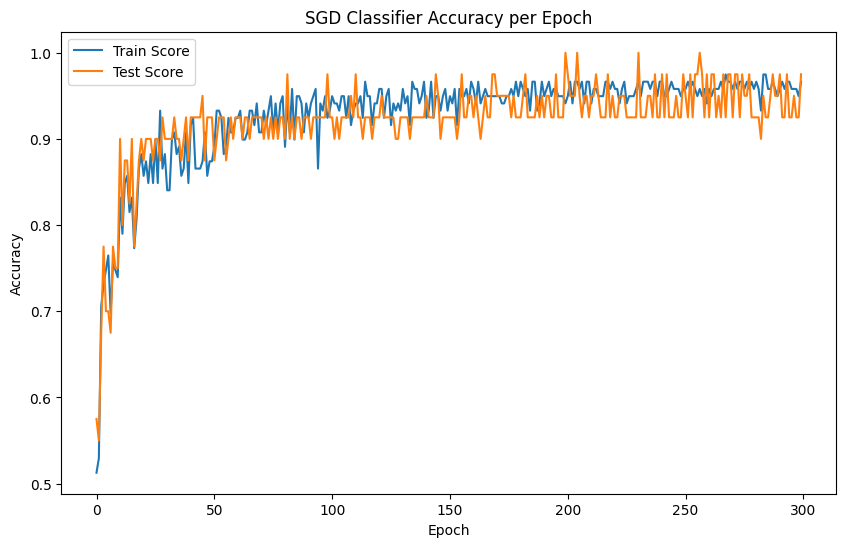

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(train_score, label='Train Score')
plt.plot(test_score, label='Test Score')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('SGD Classifier Accuracy per Epoch')
plt.legend()
plt.show()

In [44]:
optimal_epoch = 100

In [45]:
sc_optimal = SGDClassifier(loss='hinge', max_iter=optimal_epoch, tol=None, random_state=42)
sc_optimal.fit(train_scaled, train_target)
score_optimal = sc_optimal.score(test_scaled, test_target)

In [46]:
print(f"\n=== 7번. 최종 비교 ===")
print(f"최적 에포크({optimal_epoch}번) 모델 테스트 정확도: {score_optimal:.4f}")
print(f"-> 에포크 10 모델({score_10:.4f})에 비해 에포크 {optimal_epoch} 모델({score_optimal:.4f})의 정확도가 크게 향상되었습니다.")


=== 7번. 최종 비교 ===
최적 에포크(100번) 모델 테스트 정확도: 0.9250
-> 에포크 10 모델(0.8750)에 비해 에포크 100 모델(0.9250)의 정확도가 크게 향상되었습니다.
